# Tokenization

In [ ]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
import os
import paper_dataset
import json
import extraction
import re
import itertools
import collections
import extraction_maps
import tqdm
import dotenv
import language_data
sns.set_theme(style="darkgrid")
sns.set_context("talk",  font_scale=1.5, rc={"lines.linewidth": 2.5})
sns.set_palette("colorblind")
YEAR_MIN = 2016
YEAR_MAX = 2025

dotenv.load_dotenv()
tqdm.tqdm.pandas()
glottolog = language_data.get_glottolog_instance()
_ = language_data.get_language_index()

## Counting papers

In [46]:
ds = paper_dataset.load()
print(f"Total papers: {len(ds)}")
ds = ds[((ds["year"] >= YEAR_MIN) & (ds["year"] <= YEAR_MAX)) | (ds["venue"] == 'TokShop')]
print(f"Papers after filtering by year and venue: {len(ds)}")
tok = paper_dataset.load("data/tokenization.jsonl")
print(f"Total tokenization papers: {len(tok)}")
tok = tok[((tok["year"] >= YEAR_MIN) & (tok["year"] <= YEAR_MAX)) | (tok["venue"] == 'TokShop')]
print(f"Tokenization papers after filtering by year and venue: {len(tok)}")

ds = ds[paper_dataset.not_duplicate_mask(ds)]
tok = tok[paper_dataset.not_duplicate_mask(tok)]
print(f"Papers after filtering duplicates: {len(tok)}")

Total papers: 175375
Papers after filtering by year and venue: 121219
Total tokenization papers: 863
Tokenization papers after filtering by year and venue: 859
Papers after filtering duplicates: 846


In [54]:
conferences = ds.groupby("type")
# Fix missing papers 
all_selected = list(set(tok["bibtex_id"]))
all_papers = set(ds["bibtex_id"])
missing = [i for i in all_selected if i not in all_papers]
# Add the missing papers to the dataset
missing_papers = tok[tok["bibtex_id"].isin(missing)]
ds = pd.concat([ds, missing_papers], ignore_index=True)
counts = conferences.agg({"type": "count", "re_select": "sum", "topic": "sum"})
counts = counts.pivot_table(margins=True, index=counts.index, margins_name="Total", aggfunc="sum")
counts = counts.rename(columns={"type": "Papers", "re_select": "Regex", "topic": "LLM"})

In [55]:
ds[ds["bibtex_id"].isin(m)]

,bibtex_id,title,author,year,abstract,type,url,pdf_url,volume,tldr,keywords,research_area,venue,re_select,topic
119575,ZulvjdYPU3_wang2024omnijarvis,OmniJARVIS: Unified Vision-Language-Action Tok...,Zihao Wang and Shaofei Cai and Zhancun Mu and ...,2024,"This paper presents \method, a novel Vision-La...",icml,https://openreview.net/forum?id=ZulvjdYPU3,https://openreview.net/pdf/9ddb131e71752036f29...,Multi-modal Foundation Model meets Embodied AI...,"We propose a novel VLA models, OmniJARIVS, by ...","open-world, multimodal language model, decisio...",,MFM-EAI@ICML2024 Poster,True,1.0
119576,7xoeaZZyOp_shen2026cat,CAT: Content-Adaptive Image Tokenization,Junhong Shen and Kushal Tirumala and Michihiro...,2025,Most existing image tokenizers encode images i...,icml,https://openreview.net/forum?id=7xoeaZZyOp,https://openreview.net/pdf/9312b81c57617d6141b...,Tokenization Workshop,We develop an adaptive image tokenizer that co...,Image tokenization,,TokShop,True,1.0
119577,hiw5dqfWeb_jovanovic2026watermarking,Watermarking Autoregressive Image Generation,Nikola Jovanović and Ismail Labiad and Tomas S...,2025,Watermarking the outputs of generative models ...,icml,https://openreview.net/forum?id=hiw5dqfWeb,https://openreview.net/pdf/28e86f59ca0947399f5...,Tokenization Workshop,We study token-level watermarking of autoregre...,"image tokenizers, audio tokenizers, consistenc...",,TokShop,True,1.0


In [56]:
counts[["Papers", "Regex", "LLM"]]

,Papers,Regex,LLM
type,,,
acl,74668,6469,732.0
colm,781,166,7.0
iclr,8471,925,19.0
icml,11052,945,56.0
neurips,24606,2044,32.0
Total,119578,10549,846.0


In [57]:
template = """
\\begin{{tabular}}{{r|rrr}}
        \\toprule
        Venue & Papers & Regex & LLM\\\\
        \\midrule
        *CL & {:,} & {:,} & {:,} \\\\
        NeurIPS & {:,} & {:,} & {:,} \\\\
        ICML & {:,} & {:,} & {:,} \\\\
        ICLR & {:,} & {:,} & {:,} \\\\     
        CoLM & {:,} & {:,} & {:,} \\\\
        \\midrule
        Total & {:,} & {:,} & {:,} \\\\
        \\bottomrule
\\end{{tabular}}
"""
values = [int(counts[col][venue]) for venue in ["acl", "neurips", "icml", "iclr", "colm", "Total"] for col in ["Papers", "Regex", "LLM"]]
print(template.format(*values))


\begin{tabular}{r|rrr}
        \toprule
        Venue & Papers & Regex & LLM\\
        \midrule
        *CL & 74,668 & 6,469 & 732 \\
        NeurIPS & 24,606 & 2,044 & 32 \\
        ICML & 11,052 & 945 & 56 \\
        ICLR & 8,471 & 925 & 19 \\     
        CoLM & 781 & 166 & 7 \\
        \midrule
        Total & 119,578 & 10,549 & 846 \\
        \bottomrule
\end{tabular}



## Units

In [83]:
importlib.reload(extraction_maps)
importlib.reload(extraction)

<module 'extraction' from '/lnet/work/people/vico/TokSurvey/extraction.py'>

In [84]:
tok = paper_dataset.load("data/tokenization.jsonl")
mask = ((tok["year"] >= YEAR_MIN) & (tok["year"] <= YEAR_MAX)) & (paper_dataset.not_duplicate_mask(tok))
(mask == True).sum()

np.int64(846)

In [85]:
with open('data/raw_answers/unit_answer.json') as f:
    all_answers_unit = json.load(f)

In [86]:
unit_sets = [extraction.extract_units(i) for i in all_answers_unit]
all_units = sorted(list(collections.Counter(itertools.chain.from_iterable(unit_sets)).items()))
other_units = [unit for unit, _ in all_units if extraction.invert_mapping(extraction_maps.UNIT_MAPPING).get(unit, "other") == "other"]
other_units

['bts unit',
 'heartbeat',
 'monomial',
 'punctuation mark',
 'treepiece unit (subtree)',
 'trigram',
 'utterance‑boundary token']

### Frequency

In [87]:
unit_sets = [extraction.extract_units(i, extraction_maps.UNIT_MAPPING, other=True) for i in all_answers_unit]
collections.Counter(itertools.chain.from_iterable(unit_sets)).most_common()

[('subword', 340),
 ('character', 328),
 ('word', 81),
 ('bytes', 63),
 ('token (generic)', 44),
 ('morpheme', 37),
 ('syllable', 10),
 ('phonetics', 8),
 ('other', 7),
 ('sub-character', 7),
 ('biological', 7),
 ('patch', 6),
 ('sentence', 4),
 ('none', 1),
 ('image', 1),
 ('pixels', 1)]

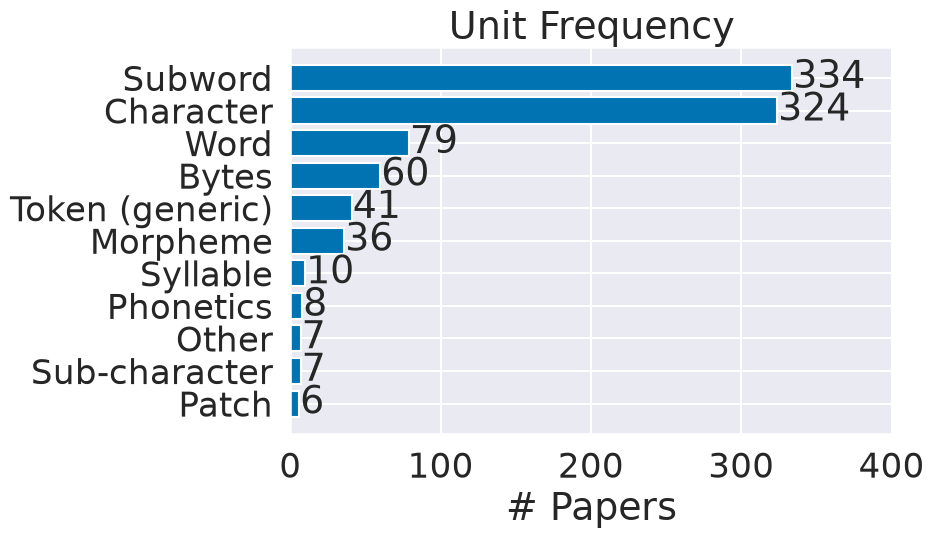

In [88]:
# Plot how many times each unit appears appears in the papers
unit_frequency = collections.Counter()
for units, is_selected in zip(unit_sets, mask.tolist()):
    if is_selected:
        unit_frequency.update(units)
unit_frequency_items = unit_frequency.most_common(11)
units, frequencies = zip(*unit_frequency_items)
plt.figure(figsize=(10, 6))
plt.barh(list(map(str.capitalize, units[::-1])), frequencies[::-1])
plt.title('Unit Frequency')
# Add the frequency values to the bars
for i, v in enumerate(frequencies[::-1]):
    plt.text(v + 0.5, i, str(v), va='center')
plt.xlabel('# Papers')
plt.tight_layout()
plt.xlim(0, max(frequencies)*1.2)
plt.savefig("plots/unit_frequency.pdf", dpi=300, bbox_inches='tight')
plt.savefig("plots/unit_frequency.png", dpi=300, bbox_inches='tight')
plt.show()

### Units per Paper

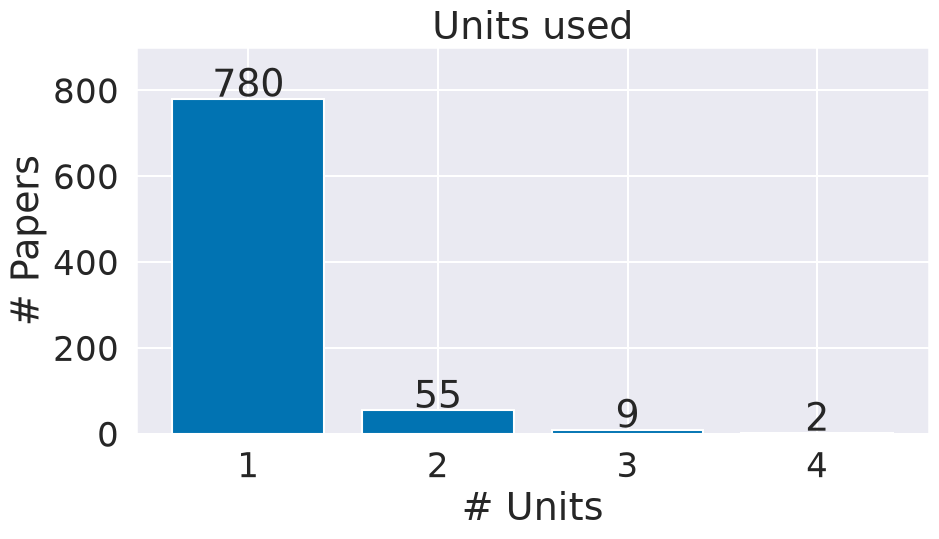

In [89]:
# Types of units per paper
counts = [len(units) for units, is_selected in zip(unit_sets, mask.tolist()) if is_selected]
max_ = max(counts)
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=range(1, max_ + 2), align='left', rwidth=0.8)
plt.xticks(range(1, max_ + 1), labels=[str(i) for i in range(1, max_ + 1)])
plt.xlabel('# Units')
plt.ylabel('# Papers')
plt.title('Units used')
# Add the count values on top of the bars
for i in range(1, max_ + 1):
    count = counts.count(i)
    plt.text(i, count + 5, str(count), ha='center')
plt.ylim(0, 900)
plt.tight_layout()
plt.savefig("plots/number_of_unit_types.pdf", bbox_inches='tight')
plt.show()

### Units Years

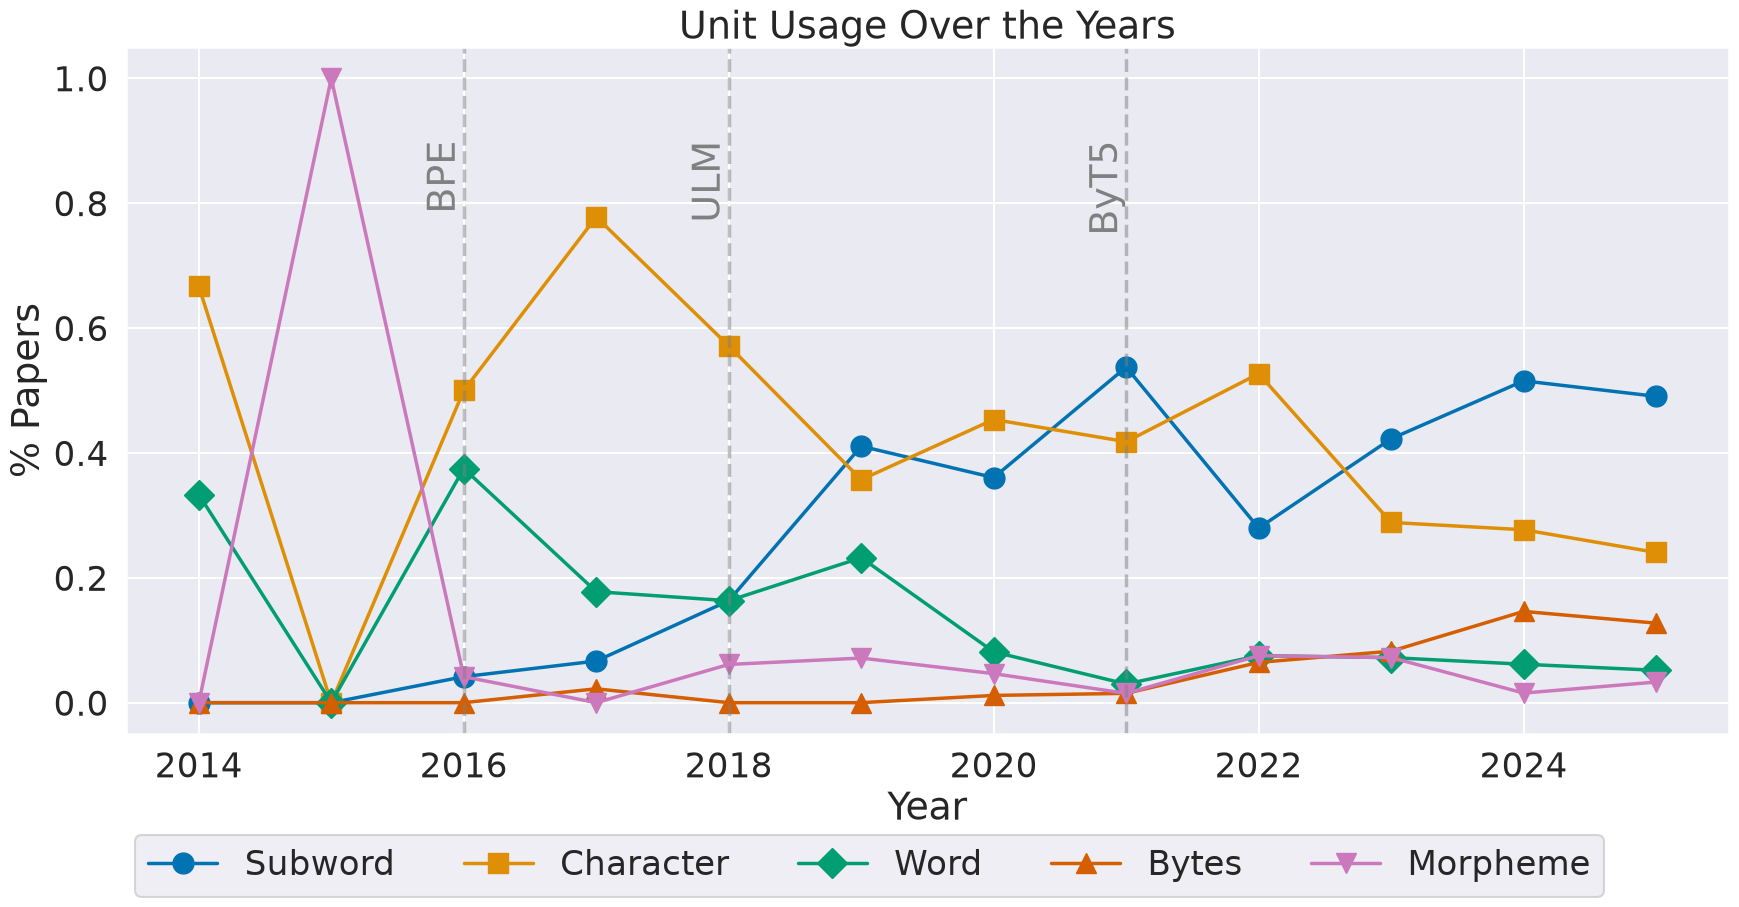

In [90]:
# Count how many times units are used over the years
# Units: subwords, characters, words, bytes, pixels, morphemes
from matplotlib import markers


years = tok.year.to_list()
year_range = list(range(min(years), max(years) + 1))
min_ = min(year_range)
units = ["subword", "character", "word", "bytes", "morpheme"]
# units = list(extraction_maps.UNIT_MAPPING.keys())
counts = {unit: [0] * len(year_range) for unit in units}
all_counts = [0] * len(year_range)
for unit_set, year in zip(unit_sets, years):
    for unit in units:
        if unit in unit_set:
            counts[unit][year - min_] += 1
    all_counts[year - min_] += 1
plt.figure(figsize=(18, 9))
markers = ['o', 's', 'D', '^', 'v', 'X', 'P'] * len(units)
for unit, marker in zip(units, markers):
    # Increase marker size for better visibility
    plt.plot(year_range, [i/j if j > 0 else 0 for i, j in zip(counts[unit], all_counts)], marker=marker, label=unit.capitalize(), markersize=15)
# Add milestones
milestones = [
    (2016, 'BPE', 0.9),
    (2018, 'ULM', 0.9),
    (2021, 'ByT5', 0.9),
    # (2023, 'PIXEL', 0.55)
]
for year, label, y in milestones:
    plt.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
    plt.text(year, y, label, verticalalignment='top', horizontalalignment='right', color='gray', rotation=90)
plt.title('Unit Usage Over the Years')
plt.xlabel('Year')
plt.ylabel('% Papers')
# plt.xticks(year_range)
plt.gca().figure.legend(loc="outside lower center", ncols=6, bbox_to_anchor=(0.5, -0.05))
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/unit_usage_percentage_over_time.pdf", bbox_inches='tight')
plt.show()    

## Languages

In [174]:
importlib.reload(extraction_maps)
importlib.reload(extraction)
importlib.reload(language_data)

<module 'language_data' from '/lnet/work/people/vico/TokSurvey/language_data.py'>

In [175]:
tok = paper_dataset.load("data/tokenization.jsonl") 
mask = ((tok["year"] >= YEAR_MIN) & (tok["year"] <= YEAR_MAX)) | (tok["venue"] == 'TokShop') & paper_dataset.not_duplicate_mask(tok)

In [176]:
with open('data/raw_answers/language_answer.json') as f:
    all_answers_languages = json.load(f)
all_answers_languages[:5]

['* English  \n* Assamese  \n* Khasi  \n* Nyishi  \n* Mizo (inferred)',
 '* Classical Chinese  \n* Modern Chinese (traditional)',
 '* Sanskrit',
 '* English\n* Hindi\n* Telugu\n* Marathi\n* Bengali\n* Gujarati\n* Malayalam\n* Kannada\n* Odia\n* Punjabi\n* Sanskrit\n* Tamil\n* Urdu\n* Inuktitut',
 '* Ukrainian  \n* Arabic  \n* English']

In [177]:
lang_sets = [extraction.extract_languages(i) for i in all_answers_languages]
all_langs = sorted(list(set(itertools.chain.from_iterable(lang_sets))))
print(len(all_langs), 'languages found before cleaning')

576 languages found before cleaning


In [178]:
for lang in all_langs:
    if language_data.map_to_glottolog(lang) is language_data.NO_LANGUAGE:
        print(lang)

...
f
latm
li-x-east


In [179]:
glottolang_sets = []
for lang_set in tqdm.tqdm(lang_sets):
    lset = set()
    for lang in lang_set:                    
        languoid = language_data.map_to_glottolog(lang)
        lset.add(languoid)
    glottolang_sets.append(lset)

100%|██████████| 863/863 [00:00<00:00, 123652.66it/s]


In [180]:
macroareas = collections.Counter()
russian_languages = 0
macroareas_sets = []
rep = {"Eurasia": "Asia"}
for glottolang_set, valid in tqdm.tqdm(zip(glottolang_sets, mask.tolist())):
    if not valid:
        continue
    areas = set()
    russia = False
    for lang in glottolang_set:
        if language_data.is_european(lang):
            areas.add("Europe")
        elif language_data.is_exclusive_russian(lang):
            areas.add("Europe")
            russia = True
        else:
            areas.update(language_data.get_macroarea(lang, rep))
    if russia:
        russian_languages += 1
    if len(areas) == 0:
        areas = {"None",}
    macroareas.update(areas)
    macroareas_sets.append(tuple(sorted(list(areas))))
for i in macroareas.most_common():
    print(i)
print("russia:", russian_languages)
for i in collections.Counter(macroareas_sets).most_common():
    print(i)

863it [00:00, 2436.03it/s]

('Europe', 619)
('Asia', 471)
('None', 184)
('Africa', 93)
('North America', 47)
('Papunesia', 39)
('South America', 17)
('Programming Languages', 13)
('Biological Sequences', 2)
russia: 12
(('Europe',), 276)
(('Asia',), 183)
(('Asia', 'Europe'), 140)
(('Asia', 'Europe', 'None'), 63)
(('Africa', 'Asia', 'Europe', 'None'), 28)
(('Europe', 'None'), 26)
(('None',), 24)
(('Africa', 'Asia', 'Europe', 'None', 'Papunesia'), 10)
(('Africa', 'Europe'), 10)
(('North America',), 8)
(('Europe', 'North America'), 8)
(('Africa', 'Asia', 'Europe', 'None', 'North America', 'Papunesia', 'South America'), 7)
(('Europe', 'Programming Languages'), 7)
(('Africa',), 6)
(('Africa', 'Asia', 'Europe', 'None', 'North America', 'Papunesia'), 5)
(('Programming Languages',), 5)
(('Africa', 'Asia', 'Europe'), 5)
(('Africa', 'Asia', 'Europe', 'North America', 'Papunesia'), 4)
(('Asia', 'Europe', 'North America'), 3)
(('Africa', 'Asia', 'None'), 3)
(('Africa', 'Europe', 'None'), 3)
(('Asia', 'Europe', 'None', 'Papune

### Macroareas

None: 184
Europe: 619
Asia: 471
Africa: 93
North America: 47
Papunesia: 39
South America: 17
Australia: 0


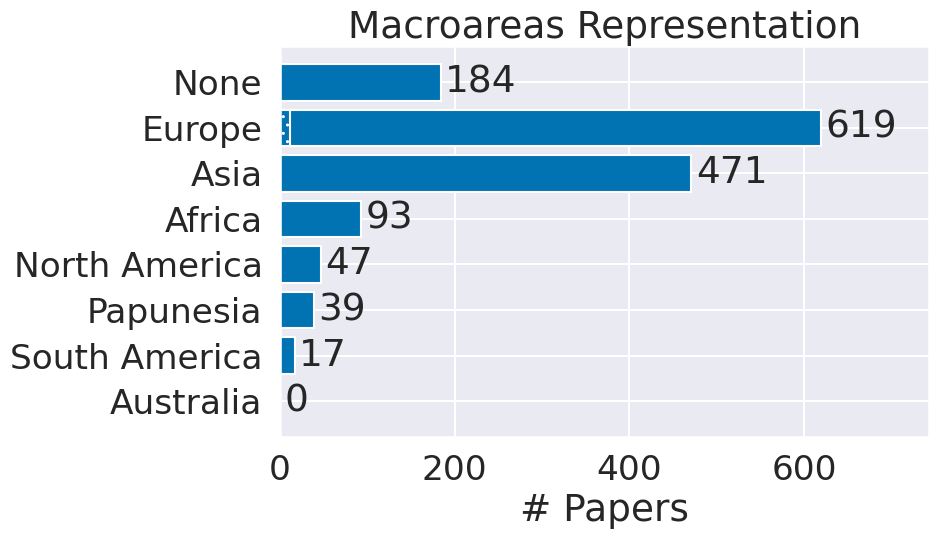

In [181]:
# Plot macroarea counts, overlap bars with Europe (filled) and Russia (hatched)
areas = [ "None", "Europe", "Asia", "Africa", "North America", "Papunesia", "South America", "Australia"]
counts = [macroareas[area] for area in areas]
for i, area in enumerate(areas):
    print(f"{area}: {counts[i]}")
plt.figure(figsize=(10, 6))
plt.barh(areas, counts)
plt.barh(["Europe"], [russian_languages], color='C0', hatch='..', label='Russia')

plt.gca().invert_yaxis()
plt.title('Macroareas Representation')
plt.xlabel('# Papers')
# Add the frequency values to the bars
for i, v in enumerate(counts):
    plt.text(v + 5, i, str(v), va='center')
plt.xlim(0, max(counts)*1.2)
# plt.legend()
plt.tight_layout()
plt.savefig("plots/language_macroareas.pdf", bbox_inches='tight')
plt.show()

### Continent Combinations

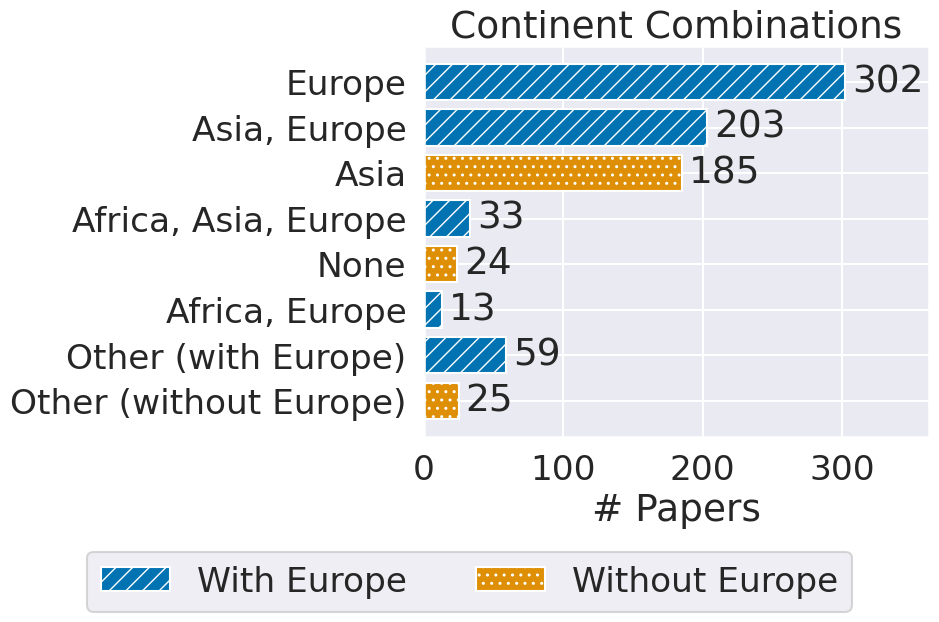

In [198]:
# Plot collections.Counter(macroareas_sets).most_common()
from matplotlib.patches import Rectangle
plt.figure(figsize=(10, 6))
# Exclude bio and prog
excluded = ["Biological Sequences", "Programming Languages"]
# Remove None unless it's the only one
macroareas_sets_no_none = [tuple(s) for s in macroareas_sets if not any(i in excluded for i in s)]
macroareas_sets_no_none = [s if len(s) == 1 else tuple(i for i in s if i != "None") for s in macroareas_sets_no_none]
macroarea_set_counts = collections.Counter(macroareas_sets_no_none).most_common()
labels, counts = zip(*macroarea_set_counts[:20])
labels = [", ".join(label) for label in labels]
n = 6
labels_plot = list(labels[:n])
labels_plot = [label if label != '' else "None" for label in labels_plot]
counts_plot = list(counts[:n])
labels_others = ["Other (with Europe)", "Other (without Europe)"]
count_others_with_europe = sum(c for l, c in macroarea_set_counts[n:] if "Europe" in l)
count_others_without_europe = sum(c for l, c in macroarea_set_counts[n:] if "Europe" not in l)
labels_plot += labels_others
counts_plot += [count_others_with_europe, count_others_without_europe]
plt.barh(labels_plot, counts_plot, color=['C0' if 'Europe' in label and 'without' not in label else 'C1' for label in labels_plot], hatch=['//' if 'Europe' in label and 'without' not in label else '..' for label in labels_plot])
plt.gca().invert_yaxis()
plt.title('Continent Combinations')
plt.xlabel('# Papers')
# Add a legend for Europe color
plt.gca().figure.legend(handles=[Rectangle((0,0),1,1, facecolor='C0', hatch='//'), Rectangle((0,0),1,1, facecolor='C1', hatch='..')], labels=['With Europe', 'Without Europe'], loc='outside lower center', ncols=2, bbox_to_anchor=(0.5, -0.1))
# Add the frequency values to the bars
for i, v in enumerate(counts_plot):
    plt.text(v + 5, i, str(v), va='center')
plt.xlim(0, max(counts_plot)*1.2)
plt.tight_layout()
plt.savefig("plots/language_macroarea_combinations.pdf", bbox_inches='tight')
plt.show()

In [196]:
macroareas_sets

[('Asia', 'Europe'),
 ('Asia',),
 ('Asia',),
 ('Asia', 'Europe', 'North America'),
 ('Europe', 'None'),
 ('Asia', 'Europe', 'None'),
 ('Asia', 'Europe'),
 ('Asia',),
 ('Asia',),
 ('Europe', 'None'),
 ('Europe',),
 ('Europe',),
 ('Europe',),
 ('North America',),
 ('Asia',),
 ('Asia', 'Europe'),
 ('Africa', 'Asia', 'Europe', 'None', 'Papunesia'),
 ('Asia',),
 ('Africa', 'Asia', 'Europe', 'North America', 'Papunesia'),
 ('Asia',),
 ('Asia', 'Europe'),
 ('Asia',),
 ('Europe',),
 ('Europe',),
 ('Asia', 'Europe'),
 ('Africa', 'Asia', 'Europe', 'None', 'Papunesia'),
 ('Africa', 'Asia', 'None'),
 ('Europe',),
 ('Europe',),
 ('Asia', 'Europe'),
 ('Europe',),
 ('Europe',),
 ('Asia',),
 ('Africa', 'Europe'),
 ('Europe',),
 ('Asia', 'Europe'),
 ('Asia',),
 ('Africa', 'Asia', 'Europe', 'None'),
 ('Europe',),
 ('Europe',),
 ('Europe',),
 ('Asia', 'Europe'),
 ('Asia', 'Europe', 'None'),
 ('Europe',),
 ('Europe',),
 ('Europe',),
 ('Europe',),
 ('Africa', 'Asia', 'Europe', 'None', 'North America', 'Pap

### Families

In [54]:
family_counts = collections.Counter()
for glottolang_set, valid in tqdm.tqdm(zip(glottolang_sets, mask.tolist())):
    if not valid:
        continue
    families = set()
    for lang in glottolang_set:
        family = language_data.get_family(lang)
        if family is None:
            if lang.category == 'Family':
                family = lang.name
            else:                
                family = "None"
        families.add(family)
    for family in families:
        family_counts[family] += 1
for i in family_counts.most_common(20):
    print(i)

863it [00:00, 2794.63it/s]

('Indo-European', 644)
('Sino-Tibetan', 263)
('Afro-Asiatic', 162)
('Japonic', 140)
('Turkic', 125)
('Uralic', 120)
('Koreanic', 107)
('Austronesian', 79)
('Atlantic-Congo', 77)
('Austroasiatic', 71)
('Dravidian', 62)
('None', 53)
('Tai-Kadai', 52)
('Mongolic-Khitan', 33)
('Kartvelian', 22)
('Eskimo-Aleut', 15)
('Quechuan', 15)
('Uto-Aztecan', 15)
('Mayan', 13)
('Algic', 10)


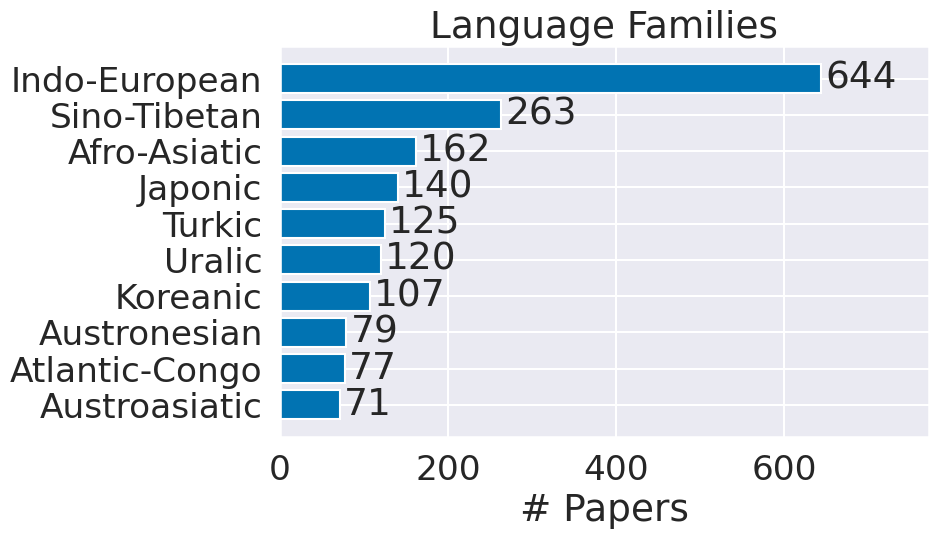

In [55]:
# Plot family counts
most_common_families = family_counts.most_common(10)
families, counts = zip(*most_common_families)
plt.figure(figsize=(10, 6))
plt.barh(families, counts)
plt.gca().invert_yaxis()
plt.title('Language Families')
plt.xlabel('# Papers')
# Add the frequency values to the bars
for i, v in enumerate(counts):
    plt.text(v + 5, i, str(v), va='center')
plt.xlim(0, max(counts)*1.2)
plt.tight_layout()
plt.savefig("plots/language_families.pdf", bbox_inches='tight')
plt.show()

### Languages

In [56]:
unique_languages = list(set(itertools.chain.from_iterable(glottolang_sets)))
print("Unique languages:", len(unique_languages))
freq = collections.Counter()
for langs in glottolang_sets:
    freq.update([i.name if i else 'None' for i in langs])
freq.most_common(20)

Unique languages: 453


[('English', 536),
 ('Chinese', 234),
 ('German', 210),
 ('French', 144),
 ('Japanese', 141),
 ('Spanish', 138),
 ('Russian', 130),
 ('Arabic', 126),
 ('Turkish', 113),
 ('Korean', 107),
 ('Hindi', 105),
 ('Italian', 96),
 ('Finnish', 93),
 ('Czech', 84),
 ('Portuguese', 78),
 ('Standard Indonesian', 65),
 ('Vietnamese', 62),
 ('Hungarian', 61),
 ('Dutch', 60),
 ('Modern Hebrew', 54)]

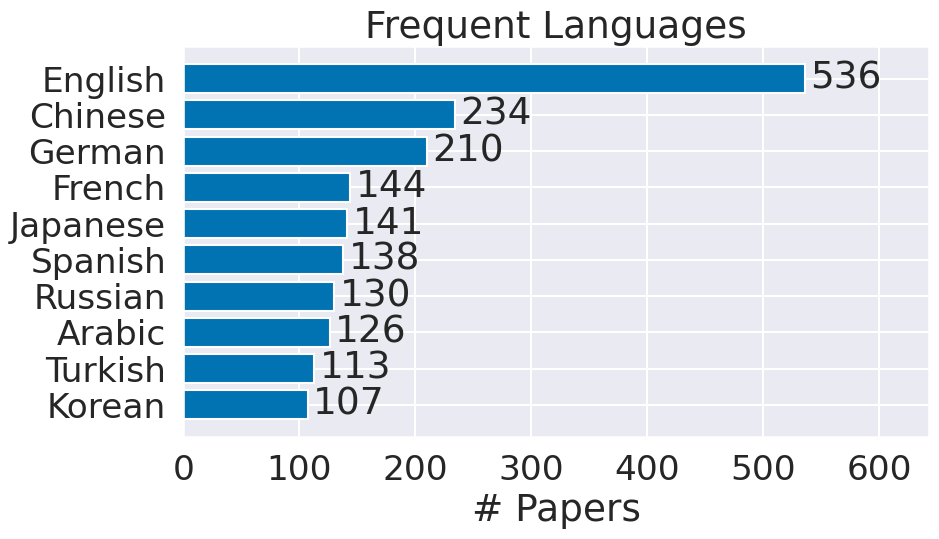

In [57]:
# Plot the most common languages
most_common = freq.most_common(10)
languages, counts = zip(*most_common)
plt.figure(figsize=(10, 6))
plt.barh(languages, counts)
# plt.xticks(rotation=90)
plt.xlabel('# Papers')
plt.gca().invert_yaxis()
plt.title('Frequent Languages')
# Add the frequency values to the bars
for i, v in enumerate(counts):
    plt.text(v + 5, i, str(v), va='center')
plt.xlim(0, max(counts)*1.2)
plt.tight_layout()
plt.savefig("plots/common_languages.pdf", bbox_inches='tight')
plt.show()  


### Venues

Max number of languages in a paper: 185
Average number of languages in a paper: 6.142025611175786
Median number of languages in a paper: 2
Number of papers with only 1 language: 338
Number of papers with no languages: 19
90th percentile of number of languages in a paper: 12


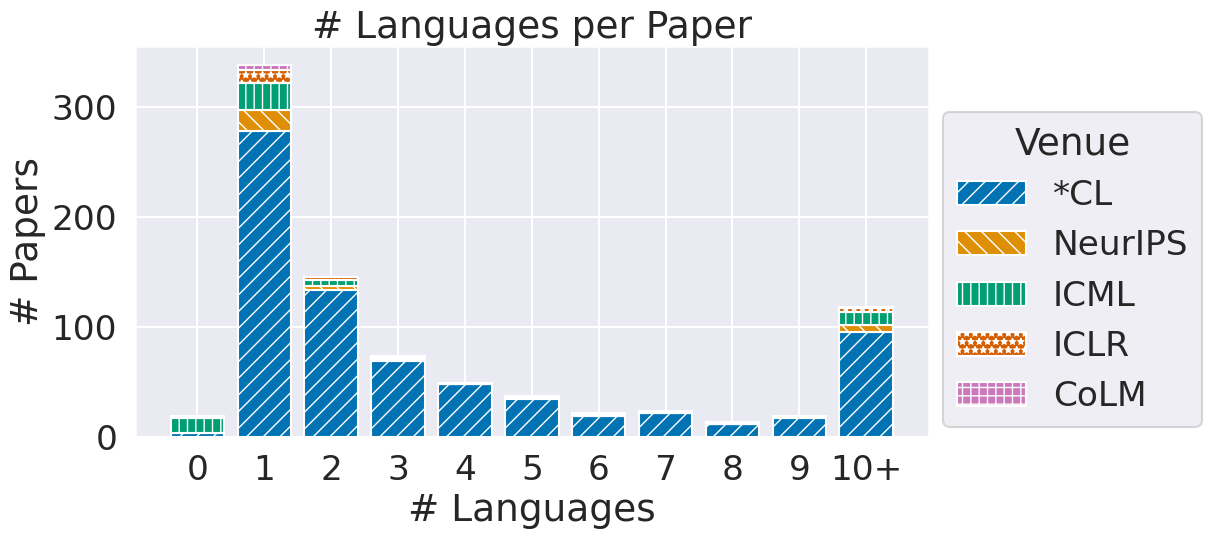

In [99]:
# Plot number of unique languages per paper, stack based on type of paper
# Add 10+ columns
n_langs = [len(langs) for langs, valid in zip(glottolang_sets, mask.tolist()) if valid]
print("Max number of languages in a paper:", max(n_langs))
print("Average number of languages in a paper:", sum(n_langs) / len(n_langs))
print("Median number of languages in a paper:", sorted(n_langs)[len(n_langs)//2])
print("Number of papers with only 1 language:", sum(1 for n in n_langs if n == 1))
print("Number of papers with no languages:", sum(1 for n in n_langs if n == 0))
print("90th percentile of number of languages in a paper:", sorted(n_langs)[int(len(n_langs) * 0.9)])

venue_map = {
    "acl": "*CL",
    "neurips": "NeurIPS",
    "icml": "ICML",
    "iclr": "ICLR",
    "colm": "CoLM",
}
# Plot number of unique languages per paper, stacked based on type of paper
n_langs_by_type = {}
for paper_type in tok['type'].unique():
    n_langs_by_type[paper_type] = [
        len(langs) for langs, valid, paper_type_filter in zip(
            glottolang_sets, mask.tolist(), tok["type"].to_list()
        ) if valid and paper_type_filter == paper_type
    ]

# plt.figure(figsize=(18, 9))
plt.figure(figsize=(10, 6))
n = 10
bins = range(0, n + 2)
# for paper_type, counts in n_langs_by_type.items():
#     plt.hist(counts, bins=bins, align='left', rwidth=0.8, label=venue_map.get(paper_type, paper_type), alpha=1, stacked=True)    
counts = {}

for paper_type, langs in n_langs_by_type.items():
    counts[paper_type] = [i if i < n else n for i in langs]
# Add filling patterns based on venue
hatches = ['//', '\\\\', '||', '**', '++']
plt.hist(counts.values(), bins=bins, align='left', rwidth=0.8, label=[venue_map.get(paper_type, paper_type) for paper_type in n_langs_by_type.keys()], alpha=1, stacked=True, hatch=hatches)

plt.xticks(range(0,n+1), [str(i) for i in range(0, n)] + [f"{n}+"] )
plt.xlabel('# Languages')
plt.ylabel('# Papers')
plt.title('# Languages per Paper')
# plt.legend(title='Venue')
# plt.legend()
plt.gca().figure.legend(loc="outside right center", ncols=1, bbox_to_anchor=(1.25, 0.5), title='Venue')
# plt.gca().figure.legend(loc="outside lower center", ncols=5, bbox_to_anchor=(0.5, -0.15), title='Venue')
plt.tight_layout()
plt.savefig("plots/languages_per_paper.pdf", bbox_inches='tight')
plt.show()

### Years

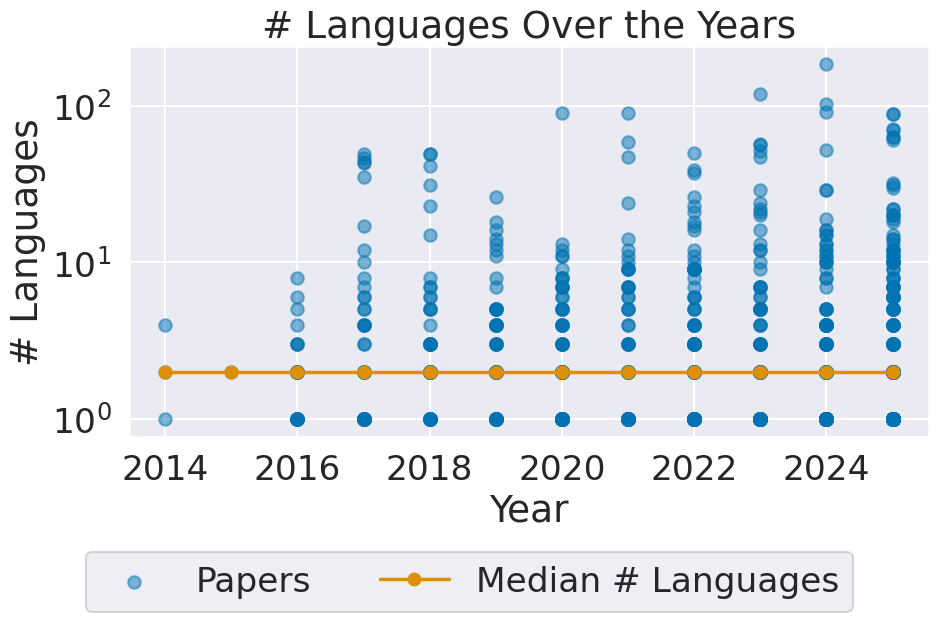

In [187]:
# Number of languages over the years, scatter plot and line plot of median number of languages
years = tok[paper_dataset.not_duplicate_mask(tok)]['year'].to_list()
n_langs = [len(langs) for langs, valid in zip(glottolang_sets, paper_dataset.not_duplicate_mask(tok).to_list()) if valid]
plt.figure(figsize=(10, 6))
plt.scatter(years, n_langs, alpha=0.5, label='Papers')
# Line plot of median number of languages per year
year_langs = {}
for year, langs in zip(years, n_langs):
    if year not in year_langs:
        year_langs[year] = []
    year_langs[year].append(langs)
year_median_langs = {year: sorted(langs)[len(langs) // 2] for year, langs in year_langs.items()}
year_mean_langs = {year: sum(langs) / len(langs) for year, langs in year_langs.items()}
year_max_langs = {year: max(langs) for year, langs in year_langs.items()}
year_mode_langs = {year: collections.Counter(langs).most_common(1)[0][0] for year, langs in year_langs.items()}
plt.plot(list(year_median_langs.keys()), list(year_median_langs.values()), color='C1', label='Median # Languages', marker='o')
# plt.plot(list(year_mean_langs.keys()), list(year_mean_langs.values()), color='C2', label='Mean # Languages', marker='s')
# plt.plot(list(year_max_langs.keys()), list(year_max_langs.values()), color='C3', label='Max # Languages', marker='^')
# plt.plot(list(year_mode_langs.keys()), list(year_mode_langs.values()), color='C4', label='Mode # Languages', marker='x')
plt.xlabel('Year')
plt.ylabel('# Languages')
plt.yscale('log')
plt.title('# Languages Over the Years')
plt.gca().figure.legend(loc="outside lower center", ncols=3, bbox_to_anchor=(0.5, -0.1))
plt.tight_layout()
plt.savefig("plots/languages_over_time.pdf", bbox_inches='tight')
plt.show()

In [193]:
print("Median:", sorted(n_langs)[len(n_langs) // 2])
print("Mean:", sum(n_langs) / len(n_langs))
print("Max:", max(n_langs))
print("Min:", min(n_langs))

Median: 2
Mean: 6.091764705882353
Max: 185
Min: 0


### Language-specific

In [60]:
with open('data/raw_answers/language_specific_answer.json') as f:
    all_answers_lang_specific = json.load(f)
all_answers_lang_specific[:5]

['Nyishi, Khasi, Assamese',
 'Chinese',
 'Sanskrit',
 'English, Hindi, Telugu, Malayalam, Marathi, Gujarati, Bengali, Inuktitut',
 'Ukrainian, Arabic']

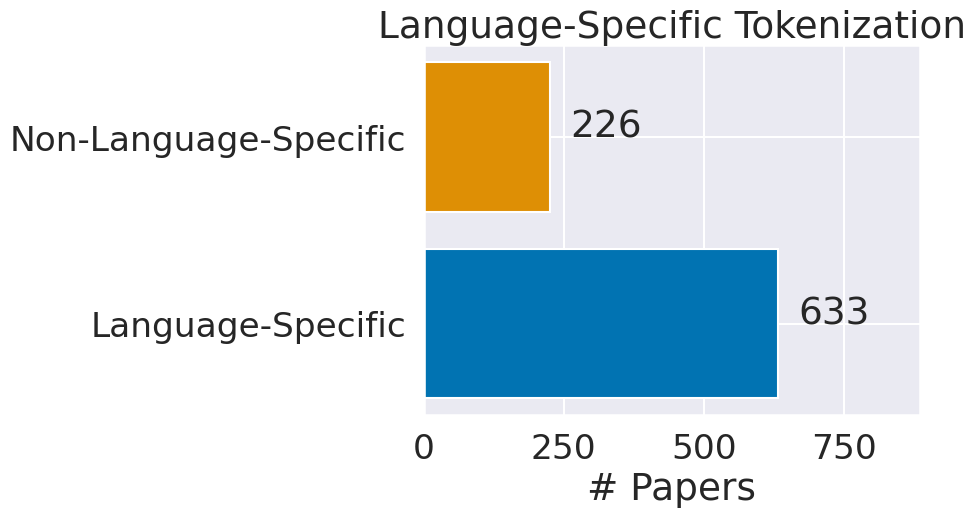

In [61]:
# Print bar plot with paper with language-specific tokenization (any language) and paper with non-language-specific tokenization ("No")
# Consider only paper with valid tokenization information (mask)
lang_specific_counts = {"Language-Specific": 0, "Non-Language-Specific": 0}
for answer, valid in zip(all_answers_lang_specific, mask.tolist()):
    if not valid:
        continue
    if answer.lower() == "no":
        lang_specific_counts["Non-Language-Specific"] += 1
    else:
        lang_specific_counts["Language-Specific"] += 1
plt.figure()
plt.barh(lang_specific_counts.keys(), lang_specific_counts.values(), color=['C0', 'C1'])
plt.title('Language-Specific Tokenization')
plt.xlabel('# Papers')
# Add the frequency values to the bars
for i, v in enumerate(lang_specific_counts.values()):
    plt.text(v + 100, i, str(v), ha='center')
plt.xlim(0, max(lang_specific_counts.values())*1.4)
# plt.tight_layout()
plt.savefig("plots/language_specific_tokenization.pdf", bbox_inches='tight')
plt.show()

## Intrinsic vs Extrinsic

In [199]:
importlib.reload(extraction_maps)
importlib.reload(extraction)

<module 'extraction' from '/lnet/work/people/vico/TokSurvey/extraction.py'>

In [200]:
tok = paper_dataset.load("data/tokenization.jsonl")
mask = ((tok["year"] >= YEAR_MIN) & (tok["year"] <= YEAR_MAX)) | (tok["venue"] == 'TokShop') & paper_dataset.not_duplicate_mask(tok)

In [201]:
with open('data/raw_answers/evaluation_extrinsic_answer.json') as f:
    all_answers_tasks = json.load(f)
with open('data/raw_answers/evaluation_intrinsic_answer.json') as f:
    all_answers_metrics = json.load(f)

In [206]:
has_extrinsic = [extraction.has_evaluation(answer) for answer, valid in zip(all_answers_tasks, mask.tolist()) if valid]
has_intrinsic = [extraction.has_evaluation(answer) for answer, valid in zip(all_answers_metrics, mask.tolist()) if valid]
has_both = [e and i for e, i in zip(has_extrinsic, has_intrinsic)]
has_extrinsic_only = [e and not i for e, i in zip(has_extrinsic, has_intrinsic)]
has_intrinsic_only = [i and not e for e, i in zip(has_extrinsic, has_intrinsic)]
has_none = [not e and not i for e, i in zip(has_extrinsic, has_intrinsic)]
print(f"Extrinsic evaluation: {sum(has_extrinsic)} papers ({sum(has_extrinsic) / len(has_extrinsic) * 100:.1f}%), {len(has_extrinsic) - sum(has_extrinsic)} papers without")
print(f"Intrinsic evaluation: {sum(has_intrinsic)} papers ({sum(has_intrinsic) / len(has_intrinsic) * 100:.1f}%), {len(has_intrinsic) - sum(has_intrinsic)} papers without")
print(f"Both evaluations: {sum(has_both)} papers ({sum(has_both) / len(has_both) * 100:.1f}%)")
print(f"Extrinsic only: {sum(has_extrinsic_only)} papers ({sum(has_extrinsic_only) / len(has_extrinsic_only) * 100:.1f}%)")
print(f"Intrinsic only: {sum(has_intrinsic_only)} papers ({sum(has_intrinsic_only) / len(has_intrinsic_only) * 100:.1f}%)")
print(f"No evaluation: {sum(has_none)} papers ({sum(has_none) / len(has_none) * 100:.1f}%)")

Extrinsic evaluation: 549 papers (63.9%), 310 papers without
Intrinsic evaluation: 437 papers (50.9%), 422 papers without
Both evaluations: 217 papers (25.3%)
Extrinsic only: 332 papers (38.6%)
Intrinsic only: 220 papers (25.6%)
No evaluation: 90 papers (10.5%)


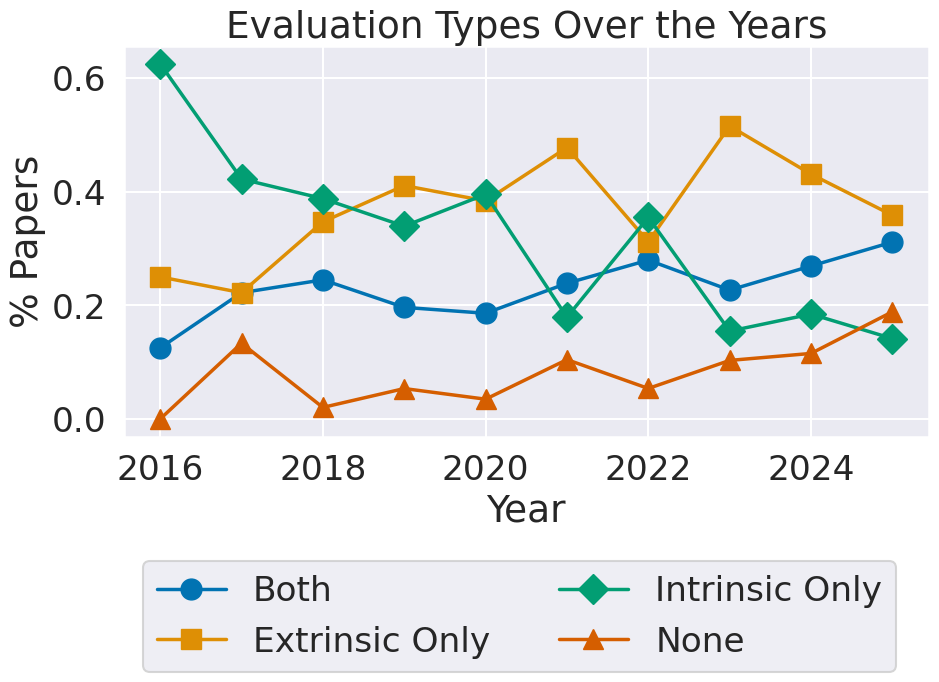

In [203]:
# Line plot of percentage of papers with only extrinsic, only intrinsic, both, or no evaluation over the years
years = tok[mask]['year'].to_list()
evaluation_categories = {
    "Both": has_both,
    "Extrinsic Only": has_extrinsic_only,
    "Intrinsic Only": has_intrinsic_only,
    "None": has_none
}
year_category_counts = {category: [0] * (max(years) - min(years) + 1) for category in evaluation_categories}
year_total_counts = [0] * (max(years) - min(years) + 1)
for year, *categories in zip(years, has_both, has_extrinsic_only, has_intrinsic_only, has_none):
    year_total_counts[year - min(years)] += 1
    for category, is_in_category in zip(evaluation_categories.keys(), categories):
        if is_in_category:
            year_category_counts[category][year - min(years)] += 1
plt.figure(figsize=(10, 6))
markers = ['o', 's', 'D', '^']
for category, counts in year_category_counts.items():
    plt.plot(range(min(years), max(years) + 1), [c / t if t > 0 else 0 for c, t in zip(counts, year_total_counts)], label=category, marker=markers.pop(0) if markers else 'o', markersize=15)
plt.xlabel('Year')
plt.ylabel('% Papers')
plt.title('Evaluation Types Over the Years')
# Legend rightoutside the plot, 1 columns
# plt.gca().figure.legend(loc="outside right center", ncols=1, bbox_to_anchor=(1.25, 0.5))
plt.gca().figure.legend(loc="outside lower center", ncols=2, bbox_to_anchor=(0.55, -0.2))
plt.tight_layout()
plt.savefig("plots/evaluation_types_over_time.pdf", bbox_inches='tight')
plt.show()

In [204]:
year_category_counts

{'Both': [3, 10, 12, 11, 16, 16, 26, 22, 35, 66],
 'Extrinsic Only': [6, 10, 17, 23, 33, 32, 29, 50, 56, 76],
 'Intrinsic Only': [15, 19, 19, 19, 34, 12, 33, 15, 24, 30],
 'None': [0, 6, 1, 3, 3, 7, 5, 10, 15, 40]}

In [205]:
year_total_counts

[24, 45, 49, 56, 86, 67, 93, 97, 130, 212]

## Tasks

In [50]:
importlib.reload(extraction_maps)
importlib.reload(extraction)

<module 'extraction' from '/lnet/work/people/vico/TokSurvey/extraction.py'>

In [35]:
tok = paper_dataset.load("data/tokenization.jsonl")
mask = ((tok["year"] >= YEAR_MIN) & (tok["year"] <= YEAR_MAX)) | (tok["venue"] == 'TokShop') & paper_dataset.not_duplicate_mask(tok)

In [36]:
with open('data/raw_answers/evaluation_extrinsic_answer.json') as f:
    all_answers_tasks = json.load(f)

In [43]:
task_sets = [extraction.extract_tasks(i) for i, valid in zip(all_answers_tasks, mask.tolist()) if valid]
all_tasks = sorted(list(set(itertools.chain.from_iterable(task_sets))))
print(len(all_tasks), 'tasks found before cleaning')

count = collections.Counter(list(itertools.chain.from_iterable(task_sets)))
count.most_common()

threshold = 5
print(f"Tasks with at least {threshold} papers:")
for task, c in count.most_common():
    if c < threshold:
        break
    print(task, c)

924 tasks found before cleaning
Tasks with at least 5 papers:
machine translation 136
part-of-speech tagging 43
named entity recognition 40
dependency parsing 28
hellaswag 27
mmlu 26
sentiment analysis 23
xnli 23
piqa 20
rte 17
boolq 17
mrpc 17
mnli 16
sst-2 16
language modeling 15
qqp 15
arc 14
winogrande 14
ner 13
cola 13
qnli 13
pos tagging 13
word segmentation 12
chinese word segmentation 12
gsm8k 11
natural language inference 11
question answering 11
sts-b 11
lambada 10
wnli 10
text classification 10
lemmatization 10
copa 10
openbookqa 9
triviaqa 9
winograd 8
math 7
truthfulqa 7
arc-c 7
topic classification 7
squad 7
blimp 7
humaneval 7
automatic speech recognition 6
semantic textual similarity 6
mbpp 6
paws-x 6
cute 6
sentiment classification 6
neural machine translation 6
pos 5
arc-e 5
commonsenseqa 5
summarization 5
xquad 5
race 5
drop 5


In [44]:
count.most_common()

[('machine translation', 136),
 ('part-of-speech tagging', 43),
 ('named entity recognition', 40),
 ('dependency parsing', 28),
 ('hellaswag', 27),
 ('mmlu', 26),
 ('sentiment analysis', 23),
 ('xnli', 23),
 ('piqa', 20),
 ('rte', 17),
 ('boolq', 17),
 ('mrpc', 17),
 ('mnli', 16),
 ('sst-2', 16),
 ('language modeling', 15),
 ('qqp', 15),
 ('arc', 14),
 ('winogrande', 14),
 ('ner', 13),
 ('cola', 13),
 ('qnli', 13),
 ('pos tagging', 13),
 ('word segmentation', 12),
 ('chinese word segmentation', 12),
 ('gsm8k', 11),
 ('natural language inference', 11),
 ('question answering', 11),
 ('sts-b', 11),
 ('lambada', 10),
 ('wnli', 10),
 ('text classification', 10),
 ('lemmatization', 10),
 ('copa', 10),
 ('openbookqa', 9),
 ('triviaqa', 9),
 ('winograd', 8),
 ('math', 7),
 ('truthfulqa', 7),
 ('arc-c', 7),
 ('topic classification', 7),
 ('squad', 7),
 ('blimp', 7),
 ('humaneval', 7),
 ('automatic speech recognition', 6),
 ('semantic textual similarity', 6),
 ('mbpp', 6),
 ('paws-x', 6),
 ('cut

In [51]:
task_sets = [extraction.extract_tasks(i, extraction_maps.task_mapping) for i, valid in zip(all_answers_tasks, mask.tolist()) if valid]
all_tasks = sorted(list(set(itertools.chain.from_iterable(task_sets))))
print(len(all_tasks), 'tasks found after cleaning')
count = collections.Counter(list(itertools.chain.from_iterable(task_sets)))

587 tasks found after cleaning


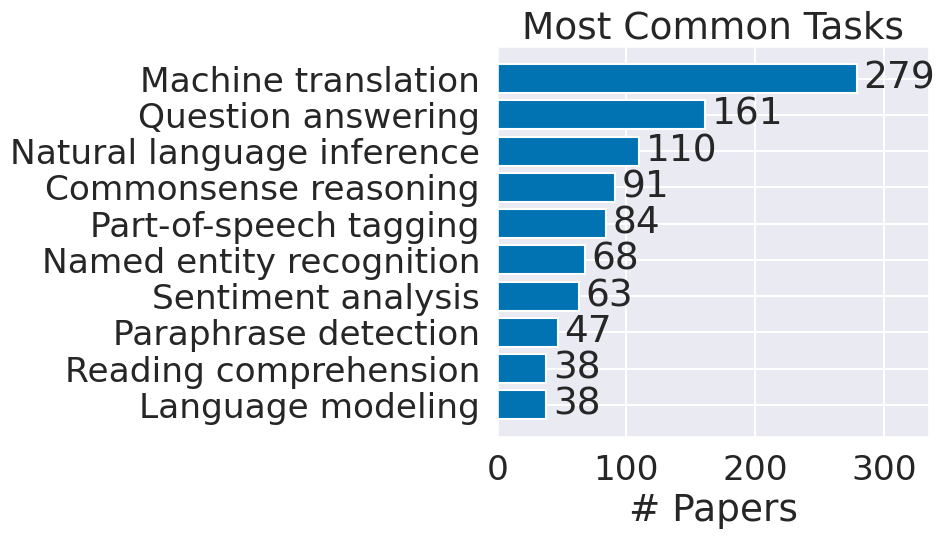

In [54]:
# barh plot of most common tasks
most_common_tasks = count.most_common(10)
tasks, frequencies = zip(*most_common_tasks)
plt.figure(figsize=(10, 6))
plt.barh(list(map(str.capitalize, tasks[::-1])), frequencies[::-1])
plt.title('Most Common Tasks')
# Add the frequency values to the bars
for i, v in enumerate(frequencies[::-1]):
    plt.text(v + 5, i, str(v), va='center')
plt.xlabel('# Papers')
plt.xlim(0, max(frequencies)*1.2)
plt.tight_layout()
plt.savefig("plots/common_tasks.pdf", bbox_inches='tight')
plt.show()

## Metrics

In [111]:
importlib.reload(extraction_maps)
importlib.reload(extraction)

<module 'extraction' from '/lnet/work/people/vico/TokSurvey/extraction.py'>

In [112]:
tok = paper_dataset.load("data/tokenization.jsonl")
mask = ((tok["year"] >= YEAR_MIN) & (tok["year"] <= YEAR_MAX)) | (tok["venue"] == 'TokShop') & paper_dataset.not_duplicate_mask(tok)

In [113]:
with open('data/raw_answers/evaluation_intrinsic_answer.json') as f:
    all_answers_metrics = json.load(f)

In [114]:
metric_sets = [extraction.extract_metrics(i) for i, valid in zip(all_answers_metrics, mask.tolist()) if valid]
all_metrics = sorted(list(set(itertools.chain.from_iterable(metric_sets))))
print(len(all_metrics), 'metrics found before cleaning')

metric_count = collections.Counter(itertools.chain.from_iterable(metric_sets))
threshold = 2
print(f"Metrics with at least {threshold} papers:")
for metric, c in metric_count.most_common():
    if c < threshold:
        break
    print(metric, c)

534 metrics found before cleaning
Metrics with at least 2 papers:
precision 133
recall 124
f1 score 81
f1 59
accuracy 57
f score 20
f measure 15
oov recall 14
fertility 10
segmentation accuracy 9
levenshtein distance 9
perplexity 9
match 9
token length 8
bleu 8
word accuracy 7
subword fertility 6
rényi efficiency 6
bits per byte 6
emma 6
compression rate 6
vocabulary coverage 5
tokens 5
compression ratio 5
edit distance 5
sequence length 5
coverage 5
boundary precision 5
boundary recall 5
vocabulary overlap 4
vocabulary size 4
rényi entropy 4
jaccard similarity 4
oov rate 4
segmentation f1 4
token length distribution 3
auc 3
continued words 3
spearman correlation 3
bytes per token 3
word f1 3
spearmans ρ 3
token level accuracy 3
wf 3
lf 3
fs[] 3
dice coefficient 3
f 3
error rate 3
in vocabulary recall 3
classification accuracy 3
tokenization f1 3
word segmentation f1 3
split prediction accuracy 2
type token ratio 2
corpus token count 2
cognitive plausibility 2
tokens per word 2
morphsc

In [115]:
metric_sets = [extraction.extract_metrics(i, extraction_maps.METRIC_MAPPING) for i, valid in zip(all_answers_metrics, mask.tolist()) if valid]
all_metrics = sorted(list(set(itertools.chain.from_iterable(metric_sets))))
print(len(all_metrics), 'metrics found after cleaning')
metric_count = collections.Counter(itertools.chain.from_iterable(metric_sets))
metric_count.most_common()

468 metrics found after cleaning


[('f1 score (generic)', 184),
 ('precision (generic)', 135),
 ('recall (generic)', 127),
 ('accuracy (generic)', 85),
 ('morphology', 31),
 ('segmentation', 27),
 ('compression', 21),
 ('fertility', 20),
 ('oov', 18),
 ('rényi/shannon', 15),
 ('distance', 14),
 ('token length', 13),
 ('perplexity', 13),
 ('exact match', 13),
 ('coverage', 12),
 ('token count', 12),
 ('overlap/similarity', 11),
 ('bleu', 9),
 ('correlation', 8),
 ('vocabulary overlap', 4),
 ('vocabulary size', 4),
 ('tokenization parity', 4),
 ('auc', 3),
 ('continued words', 3),
 ('wf', 3),
 ('lf', 3),
 ('fs[]', 3),
 ('type-token ratio', 2),
 ('cognitive plausibility', 2),
 ('bf', 2),
 ('wp', 2),
 ('wr', 2),
 ('lp', 2),
 ('lr', 2),
 ('rank', 2),
 ('rs[]', 2),
 ('visual task', 2),
 ('tokenization ratio', 1),
 ('tokens per word ratio', 1),
 ('oov token ratio', 1),
 ('cosine similarity of fasttext embeddings', 1),
 ('shared morphemes', 1),
 ('token efficiency', 1),
 ('sample efficiency', 1),
 ('continued word proportion',

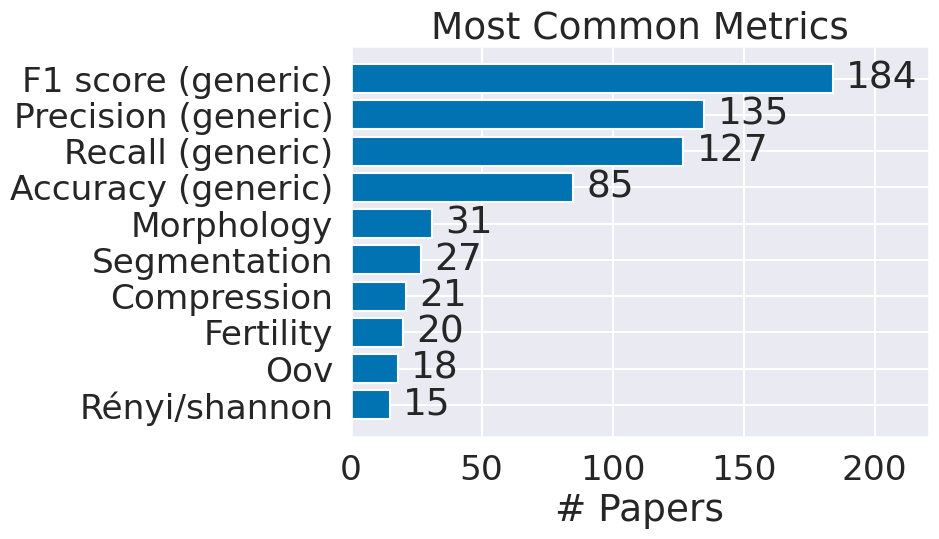

In [118]:
metric_count = collections.Counter(itertools.chain.from_iterable(metric_sets))
most_common_metrics = metric_count.most_common(10)

metrics, frequencies = zip(*most_common_metrics)
plt.figure(figsize=(10, 6))
plt.barh(list(map(str.capitalize, metrics[::-1])), frequencies[::-1])
plt.title('Most Common Metrics')

for i, v in enumerate(frequencies[::-1]):
    plt.text(v + 5, i, str(v), va='center')

plt.xlabel('# Papers')
plt.xlim(0, max(frequencies) * 1.2)
plt.tight_layout()
plt.savefig("plots/common_metrics.pdf", bbox_inches='tight')
plt.show()

## Languages and Tasks

In [119]:
importlib.reload(extraction_maps)
importlib.reload(extraction)

<module 'extraction' from '/lnet/work/people/vico/TokSurvey/extraction.py'>

In [120]:
tok = paper_dataset.load("data/tokenization.jsonl")
mask = ((tok["year"] >= YEAR_MIN) & (tok["year"] <= YEAR_MAX)) | (tok["venue"] == 'TokShop') & paper_dataset.not_duplicate_mask(tok)

In [141]:
with open('data/raw_answers/evaluation_extrinsic_answer.json') as f:
    all_answers_tasks = json.load(f)

task_sets = [extraction.extract_tasks(i, extraction_maps.task_mapping, other=True) for i, valid in zip(all_answers_tasks, mask.tolist()) if valid]
task_count = collections.Counter(list(itertools.chain.from_iterable(task_sets)))


with open('data/raw_answers/language_answer.json') as f:
    all_answers_languages = json.load(f)
lang_sets = [extraction.extract_languages(i) for i in all_answers_languages]

glottolang_sets = []
for lang_set in tqdm.tqdm(lang_sets):
    lset = set()
    for lang in lang_set:                    
        languoid = language_data.map_to_glottolog(lang)
        lset.add(languoid)
    glottolang_sets.append(lset)

100%|██████████| 863/863 [00:00<00:00, 35503.81it/s]


In [152]:
pair_counts = collections.defaultdict(int)
lang_counts = collections.defaultdict(int)
task_counts = collections.defaultdict(int)
for task_set, lang_set, valid in tqdm.tqdm(zip(task_sets, glottolang_sets, mask.tolist())):
    if not valid:
        continue

    for task in task_set:        
        for lang in lang_set:
            pair_counts[(task, lang)] += 1
            lang_counts[lang] += 1
        task_counts[task] += 1

pair_counts = collections.Counter(pair_counts)
lang_counts = collections.Counter(lang_counts)
task_counts = collections.Counter(task_counts)

859it [00:00, 81480.55it/s]


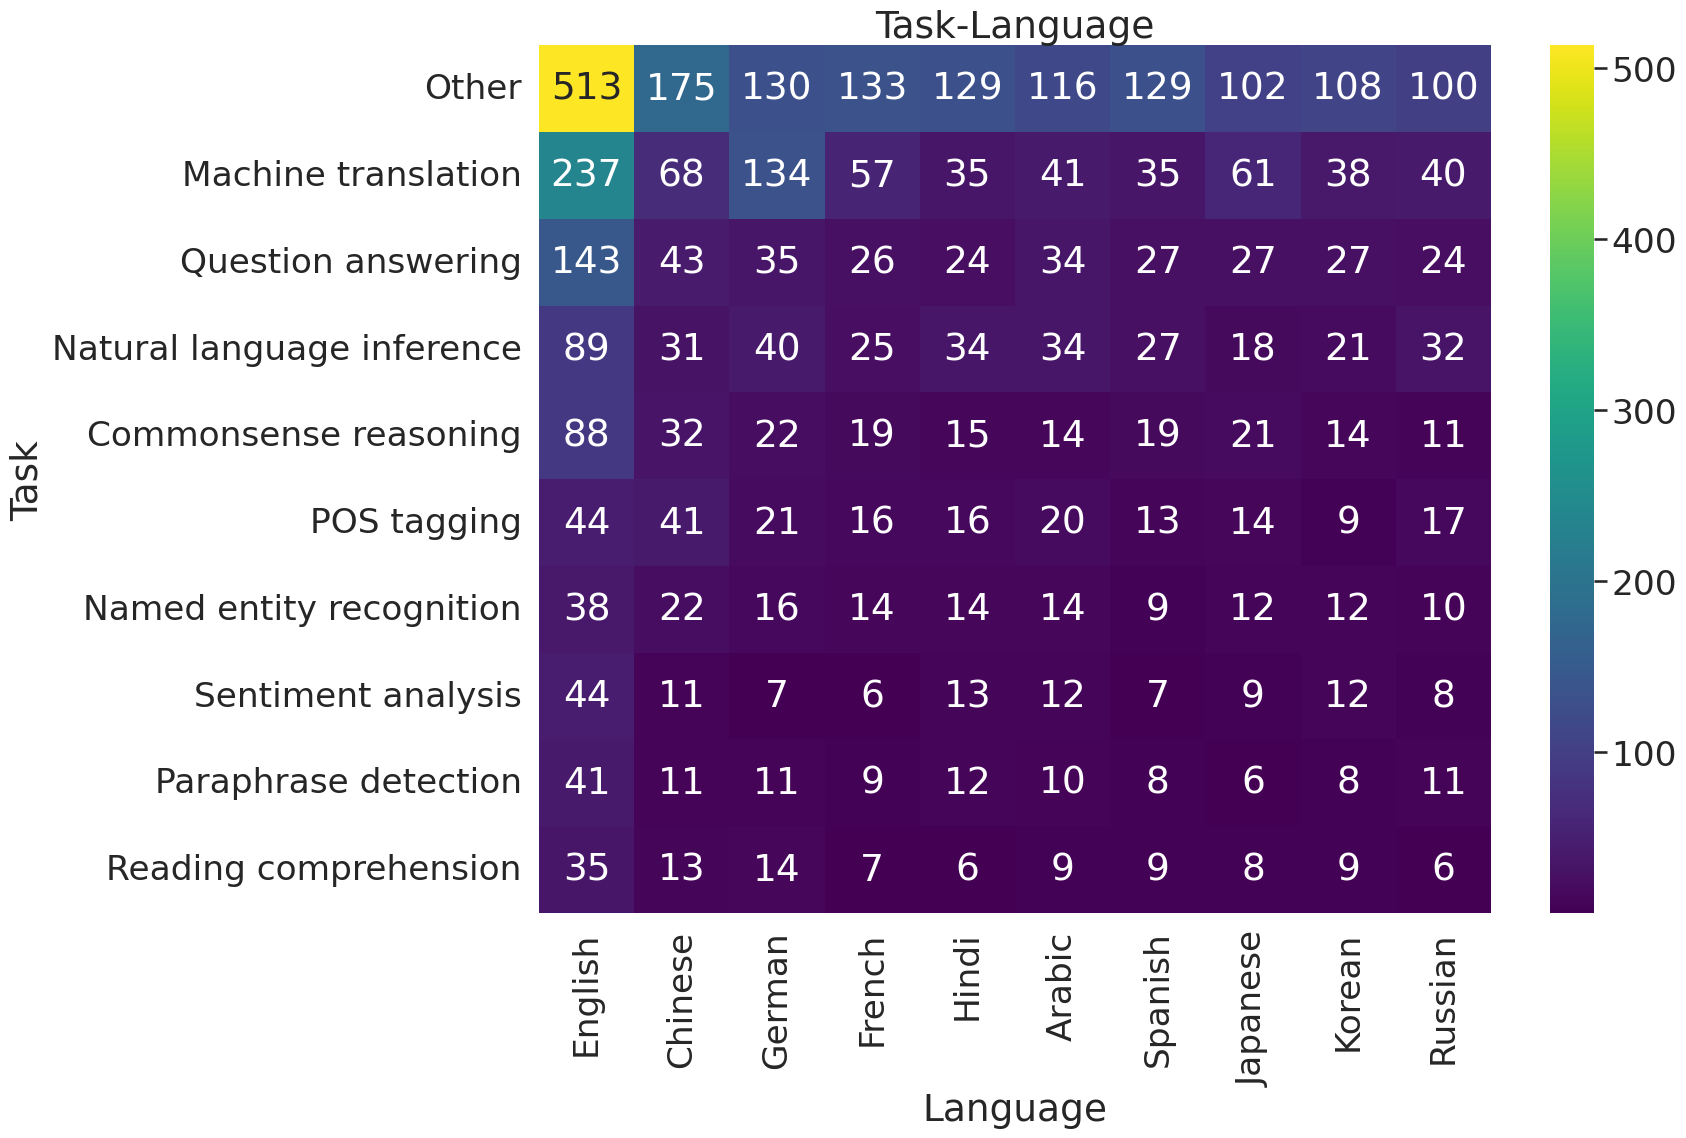

In [158]:
# Plot the pairs as a cooccurrence matrix, but only the most common languages and the most common tasks
most_common_tasks = [task for task, _ in task_counts.most_common(10)]
most_common_langs = [lang for lang, _ in lang_counts.most_common(10)]
matrix = np.zeros((len(most_common_tasks), len(most_common_langs)))
for i, task in enumerate(most_common_tasks):
    for j, lang in enumerate(most_common_langs):
        matrix[i, j] = pair_counts.get((task, lang), 0)
plt.figure(figsize=(18, 12))
task_map = {
    "part-of-speech tagging": "POS tagging",
}
yticklabels = [task_map.get(task, task.capitalize()) for task in most_common_tasks]
sns.heatmap(matrix, xticklabels=[lang.name if lang else 'None' for lang in most_common_langs], yticklabels=yticklabels, annot=True, fmt='g', cmap='viridis')
plt.title('Task-Language')
plt.xlabel('Language')
plt.ylabel('Task')
plt.tight_layout()
# plt.savefig("plots/task_language_cooccurrence.pdf", bbox_inches='tight')
plt.show()

## Languages and Units

In [149]:
# Do the same but with units and languages
with open('data/raw_answers/unit_answer.json') as f:
    all_answers_unit = json.load(f)
unit_sets = [extraction.extract_units(i, extraction_maps.UNIT_MAPPING, other=True) for i, valid in zip(all_answers_unit, mask.tolist()) if valid]
pair_counts = collections.defaultdict(int)
unit_counts = collections.defaultdict(int)
lang_counts = collections.defaultdict(int)
for unit_set, lang_set, valid in tqdm.tqdm(zip(unit_sets, glottolang_sets, mask.tolist())):
    if not valid:
        continue

    for unit in unit_set:        
        for lang in lang_set:
            pair_counts[(unit, lang)] += 1
            lang_counts[lang] += 1
        unit_counts[unit] += 1
pair_counts = collections.Counter(pair_counts)
unit_counts = collections.Counter(unit_counts)
lang_counts = collections.Counter(lang_counts)

859it [00:00, 126827.20it/s]


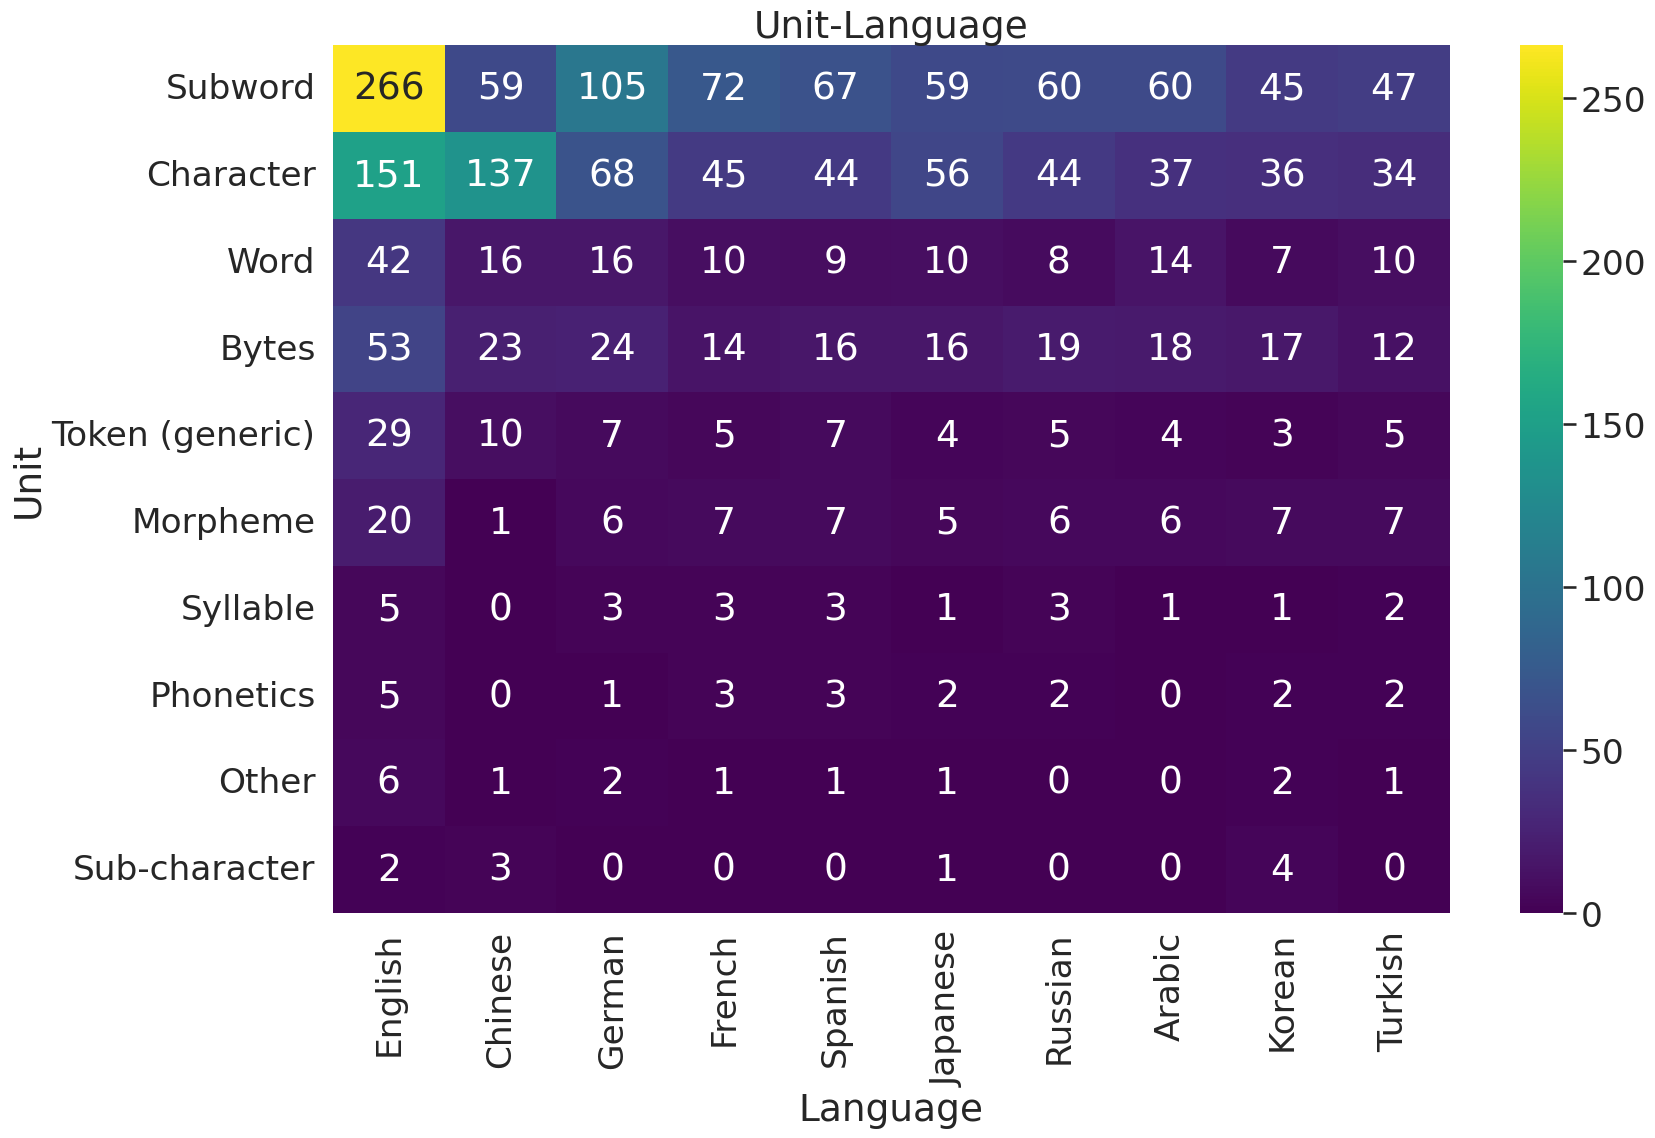

In [150]:
# Plot
most_common_units = [unit for unit, _ in unit_counts.most_common(10)]
most_common_langs = [lang for lang, _ in lang_counts.most_common(10)]
matrix = np.zeros((len(most_common_units), len(most_common_langs)))
for i, unit in enumerate(most_common_units):
    for j, lang in enumerate(most_common_langs):
        matrix[i, j] = pair_counts.get((unit, lang), 0)
plt.figure(figsize=(18, 12))
sns.heatmap(matrix, xticklabels=[lang.name if lang else 'None' for lang in most_common_langs], yticklabels=[unit.capitalize() for unit in most_common_units], annot=True, fmt='g', cmap='viridis')
plt.title('Unit-Language')
plt.xlabel('Language')
plt.ylabel('Unit')
plt.tight_layout()
# plt.savefig("plots/unit_language_cooccurrence.pdf", bbox_inches='tight')
plt.show()